<a href="https://colab.research.google.com/github/Akash14-09/Machine_Learning/blob/main/Handling_Categorical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Frequency Value Imputation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('train.csv', usecols = ['GarageQual' , 'FireplaceQu' , 'SalePrice'])

In [ ]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [ ]:
df.isnull().mean()*100


,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


<Axes: xlabel='GarageQual'>

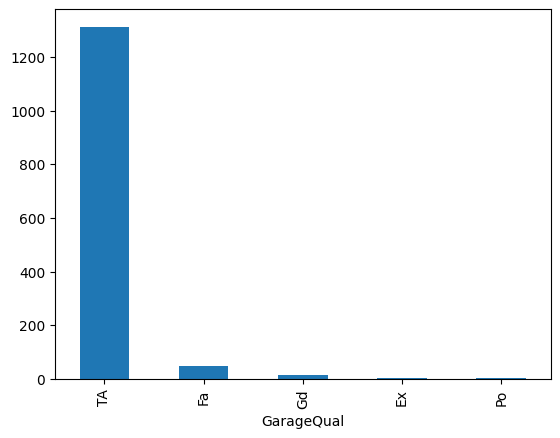

In [ ]:
df['GarageQual'].value_counts().plot(kind = 'bar')

In [ ]:
df['GarageQual'].mode()

,GarageQual
0,TA


Text(0.5, 1.0, 'GarageQual')

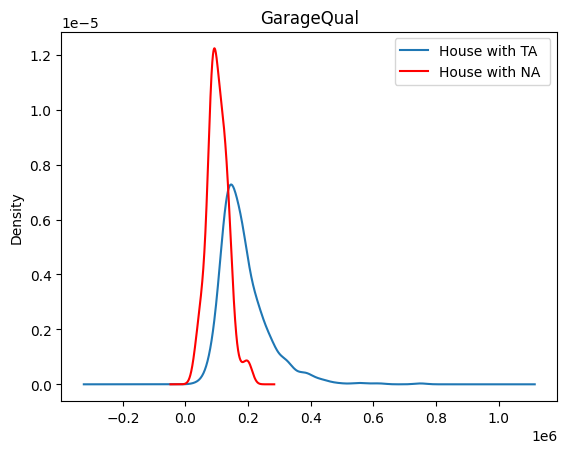

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual']  == 'TA'].plot(kind = 'kde' , ax = ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind = 'kde' , ax = ax , color = 'red')


lines , labels = ax.get_legend_handles_labels()
labels = ['House with TA' ,'House with NA ']

ax.legend(lines , labels , loc = 'best')

plt.title('GarageQual')

In [ ]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']

In [ ]:
df['GarageQual'].fillna('TA' , inplace = True)

/tmp/ipykernel_791/1522383382.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA' , inplace = True)


<Axes: xlabel='GarageQual'>

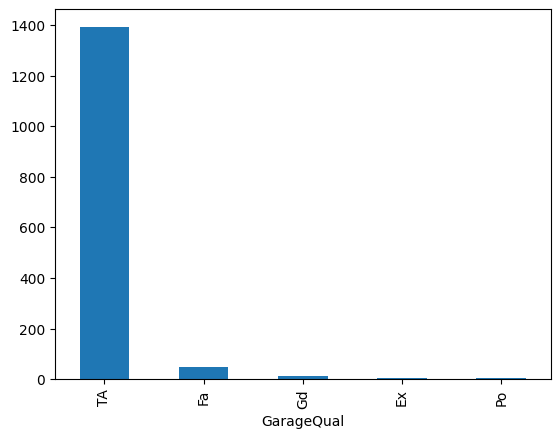

In [ ]:
df['GarageQual'].value_counts().plot(kind = 'bar')
#here we can see that the bar of the TA has increased significantly and the reason for that is that all the missing values are got replaced by TA

Text(0.5, 1.0, 'GarageQual')

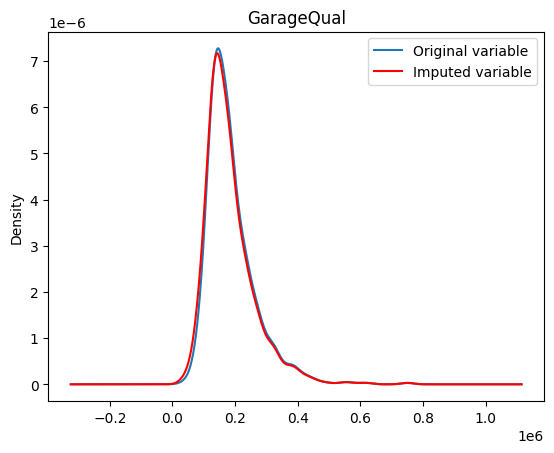

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind = 'kde' , ax = ax) #this is the old graph
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind = 'kde' , ax = ax , color = 'red')#its the new one which is marked by the red color

lines , labels = ax.get_legend_handles_labels()

labels = ['Original variable' , 'Imputed variable']

ax.legend(lines , labels , loc = 'best')

plt.title('GarageQual')


Now going to apply the same thing on the dataset in which approx 50 percent values are missing , definietely we know that there would be huge gap betweeen both the graphs


<Axes: xlabel='FireplaceQu'>

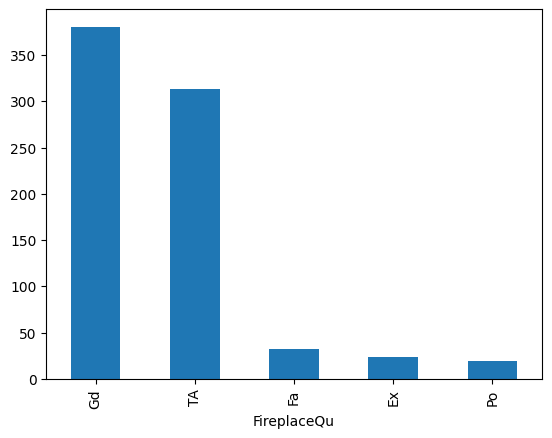

In [ ]:
df['FireplaceQu'].value_counts().plot(kind = 'bar')


In [ ]:
df['FireplaceQu'].mode()
#means Gd is the most frequent category

,FireplaceQu
0,Gd


Text(0.5, 1.0, 'FireplaceQu')

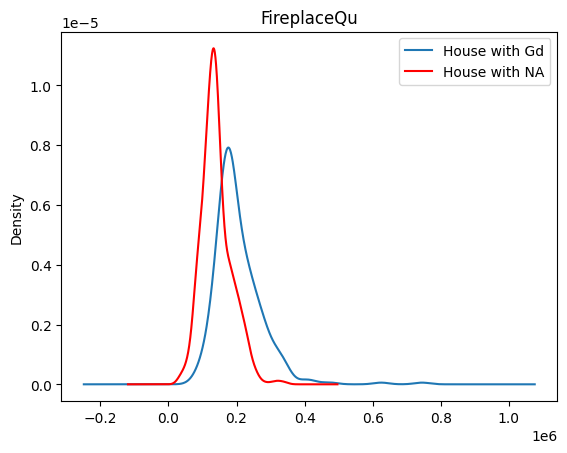

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']  == 'TA'].plot(kind = 'kde' , ax = ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind = 'kde' , ax = ax , color = 'red')


lines , labels  = ax.get_legend_handles_labels()

labels = ['House with Gd' , 'House with NA']
ax.legend(lines , labels , loc = 'best')

plt.title('FireplaceQu')


In [ ]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [ ]:
df['FireplaceQu'].fillna('Gd' , inplace = True)

/tmp/ipykernel_791/3420467924.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd' , inplace = True)


<Axes: xlabel='FireplaceQu'>

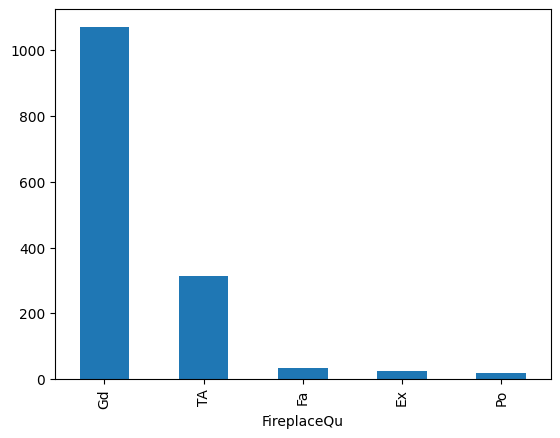

In [ ]:
df['FireplaceQu'].value_counts().plot(kind = 'bar')

Text(0.5, 1.0, 'FireplaceQu')

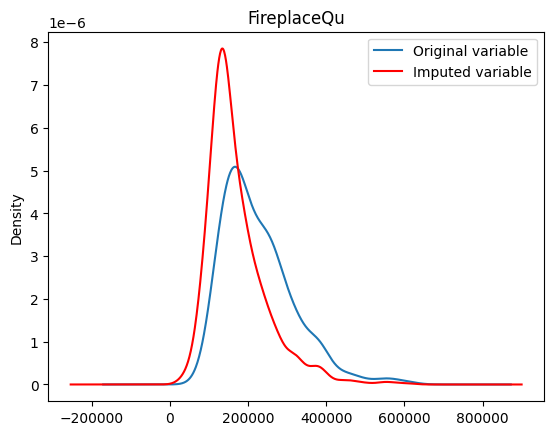

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind = 'kde' , ax = ax)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind = 'kde' , ax = ax , color = 'red')

lines , labels = ax.get_legend_handles_labels()

labels = ['Original variable' , 'Imputed variable']

ax.legend(lines , labels , loc = 'best')

plt.title('FireplaceQu')


Here above you can see there is still a difference between these two graphs even after applying the imputation

####Doing the same thing with slickitlearn

In [ ]:
from re import X
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(df.drop(columns = 'SalePrice') , df['SalePrice'] , test_size = 0.2 , random_state = 0)
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy = 'most_frequent')

In [ ]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [ ]:
imputer.statistics_

#its is showing in the first one Gd is the most frequent category and in the second one TA is the most frequent category

array(['Gd', 'TA'], dtype=object)